In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os
import json


In [9]:
def c6_data():
    df = pd.read_csv('data.csv')
    print(df.shape)

    # 删除重复值
    df.drop_duplicates(inplace=True)
    print(df.shape)

    x = df.iloc[:, :2].values
    y = df.iloc[:, 2].values

    print(x.shape, y.shape)
    
    # 归一化
    scaler_x = StandardScaler()
    scaler_x.fit(x)
    x = scaler_x.transform(x)

    scaler_y = StandardScaler()
    y = y.reshape(-1, 1)  # Reshape y to have one feature
    scaler_y.fit(y)
    y = scaler_y.transform(y)

    # 划分数据集
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=666)
    
    return x_train, x_test, y_train, y_test, scaler_x, scaler_y

# 保存处理后的数据在csv文件里
x_train, x_test, y_train, y_test, scaler_x, scaler_y = c6_data()

x_train_reshaped = x_train.reshape(x_train.shape[0], x_train.shape[1])
x_test_reshaped = x_test.reshape(x_test.shape[0], x_test.shape[1])

y_train_reshaped = y_train.reshape(y_train.shape[0], y_train.shape[1])
y_test_reshaped = y_test.reshape(y_test.shape[0], y_test.shape[1])

# 将数据转换为DataFrame
df_x_train = pd.DataFrame(x_train_reshaped)
df_x_test = pd.DataFrame(x_test_reshaped)
df_y_train = pd.DataFrame(y_train_reshaped)
df_y_test = pd.DataFrame(y_test_reshaped)

# 保存到CSV文件
df_x_train.to_csv('x_train.csv', index=False)
df_x_test.to_csv('x_test.csv', index=False)
df_y_train.to_csv('y_train.csv', index=False)
df_y_test.to_csv('y_test.csv', index=False)


(104259, 3)
(103561, 3)
(103561, 2) (103561,)


In [10]:
# Define the ANN model
model_ann = Sequential()
model_ann.add(Dense(30, activation='relu', input_dim=x_train.shape[1]))
model_ann.add(Dense(30, activation='relu'))
model_ann.add(Dense(1))
model_ann.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [11]:
model_ann.load_weights('./annmodel/model_ann_weight')


In [13]:
# Train the ANN model
history_ann = model_ann.fit(x_train, y_train, epochs=20, batch_size=200, validation_data=(x_test, y_test))


Epoch 1/20
415/415 [==============================] - 2s 2ms/step - loss: 0.1775 - mae: 0.3005 - val_loss: 0.0764 - val_mae: 0.1999
Epoch 2/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0754 - mae: 0.1959 - val_loss: 0.0747 - val_mae: 0.1895
Epoch 3/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0743 - mae: 0.1931 - val_loss: 0.0733 - val_mae: 0.1926
Epoch 4/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0738 - mae: 0.1924 - val_loss: 0.0735 - val_mae: 0.1888
Epoch 5/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0736 - mae: 0.1923 - val_loss: 0.0731 - val_mae: 0.1904
Epoch 6/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0733 - mae: 0.1922 - val_loss: 0.0726 - val_mae: 0.1927
Epoch 7/20
415/415 [==============================] - 1s 2ms/step - loss: 0.0734 - mae: 0.1924 - val_loss: 0.0728 - val_mae: 0.1936
Epoch 8/20
415/415 [==============================] - 1s 2ms/step - loss: 0.

In [17]:
# Predict using ANN model
y_pred_ann = model_ann.predict(x_test)

# Save ANN model predictions
pd.DataFrame(y_pred_ann, columns=['Predicted']).to_csv('y_pred_ann.csv', index=False)

# Calculate Mean Squared Error (MSE)
mse_ann = mean_squared_error(y_test, y_pred_ann)

# Calculate Root Mean Squared Error (RMSE)
rmse_ann = np.sqrt(mse_ann)

# Calculate Mean Absolute Error (MAE)
mae_ann = mean_absolute_error(y_test, y_pred_ann)

# Calculate R² Score
r2_ann = r2_score(y_test, y_pred_ann)

print(f"Mean Squared Error (MSE): {mse_ann}")
print(f"Root Mean Squared Error (RMSE): {rmse_ann}")
print(f"Mean Absolute Error (MAE): {mae_ann}")
print(f"R² Score: {r2_ann}")



648/648 [==============================] - 1s 828us/step
Mean Squared Error (MSE): 0.07056104786627578
Root Mean Squared Error (RMSE): 0.26563329585403217
Mean Absolute Error (MAE): 0.1865554999189562
R² Score: 0.9300361556197132


In [7]:
model_ann.save_weights('./annmodel/model_ann_weight')

In [8]:
model_ann.save('annmodel.h5')

/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [5]:
# 创建保存图片的文件夹
folder_name = "ann fig"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)


In [ ]:
#目前应用—获取训练和验证损失
train_loss = history_ann.history['loss']
val_loss = history_ann.history['val_loss']

# 计算平均验证损失
avg_val_loss = np.mean(val_loss)

# 自定义放大区间
zoom_epoch_start = 8  # 自定义起始 epoch
zoom_epoch_end = 12   # 自定义结束 epoch

# 自定义虚线框高度和宽度
rect_y_min = 0.07  # 自定义虚线框的下边界
rect_y_max = 0.078  # 自定义虚线框的上边界
rect_x_start = 8    # 自定义虚线框的左边界
rect_x_end = 12     # 自定义虚线框的右边界

# 创建保存图片的文件夹
folder_name = "ann_fig"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 绘制损失图
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(a1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'ann_loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 绘制局部放大图
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(a2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# 绘制结合图，将局部放大图嵌入到主图中
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(a1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 嵌入放大损失图
inset_ax = fig.add_axes([0.42, 0.30, 0.5, 0.5])  # [left, bottom, width, height]
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')  # 添加平均值线
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.93, 0.96, '(a2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 添加红色虚线框
rect = plt.Rectangle((rect_x_start, rect_y_min), 
                     rect_x_end - rect_x_start, 
                     rect_y_max - rect_y_min, 
                     edgecolor='red', linestyle='--', linewidth=2, facecolor='none', transform=ax1.transData)
ax1.add_patch(rect)

# 添加标注和链接
ax1.annotate('', xy=(0.6, 0.45), xycoords='axes fraction', xytext=(0.45, 0.25), textcoords='axes fraction',
             arrowprops=dict(facecolor='black', shrink=0.05, width=2))

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'combined_plot_zoomed.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

# 显示图表
plt.show()

79/79 [==============================] - 0s 842us/step


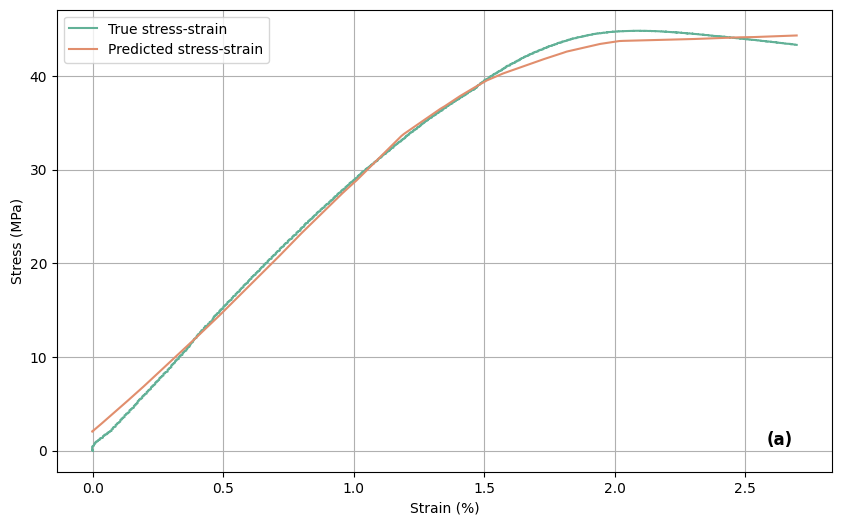

应力-应变曲线已保存并显示: ann_fig/prediction/stress_strain_curve_angle_group_5.png


In [23]:
# 确保保存图片的文件夹存在
folder_path = os.path.join('ann_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 进行预测
stress_pred_scaled = model_ann.predict(x_new_scaled)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(stress_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值
strain_threshold = 2.7  # 根据之前的阈值设置
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated, label='True stress-strain', color='#62B197')
plt.plot(strain_truncated, stress_pred_truncated, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
# plt.title('True vs Predicted Stress-Strain Curve (Angle Group 5)')
plt.grid(True)
# 在右下角添加文本 (b1)
plt.text(0.95, 0.05, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')
# 保存图像
save_path = os.path.join(folder_path, 'stress_strain_curve_angle_group_5.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")

79/79 [==============================] - 0s 785us/step


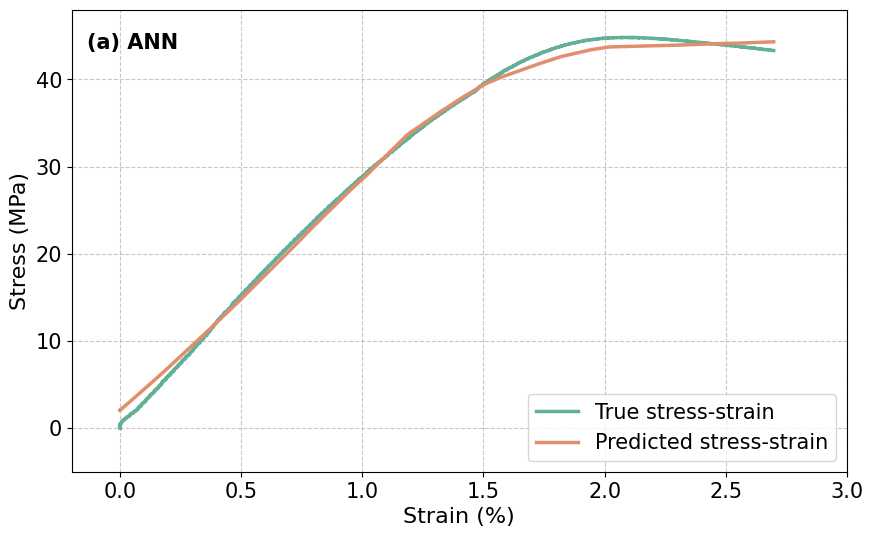

应力-应变曲线已保存并显示: ann_fig/prediction/stress_strain_curve_angle_group_5.png


In [52]:
# 确保保存图片的文件夹存在
folder_path = os.path.join('ann_fig', 'prediction')
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_x.transform(x_new)

# 进行预测
stress_pred_scaled = model_ann.predict(x_new_scaled)

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_y.inverse_transform(stress_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 使用特定的应变阈值
strain_threshold = 2.7  # 根据之前的阈值设置
valid_indices = strain_truncated < strain_threshold
strain_truncated = strain_truncated[valid_indices]
stress_true_truncated = stress_true_truncated[valid_indices]
stress_pred_truncated = stress_pred_truncated[valid_indices]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, stress_true_truncated, 
         label='True stress-strain', color='#62B197', linewidth=2.5)
plt.plot(strain_truncated, stress_pred_truncated, 
         label='Predicted stress-strain', color='#E18E6D', linewidth=2.5)

# 坐标轴与刻度字号（保持原有刻度，只改字体大小）
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)  # 保持原始整数刻度，只调大字体
plt.yticks(fontsize=15)
plt.xlim(-0.2, 3)
plt.ylim(-5, 48)

# 图例与网格
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 左上角添加文本 (a) —— 从右下角移到左上角
plt.text(0.02, 0.95, '(a) ANN', transform=plt.gca().transAxes,
         fontsize=15, fontweight='bold', ha='left', va='top')

# 保存图像
save_path = os.path.join(folder_path, 'stress_strain_curve_angle_group_5.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")


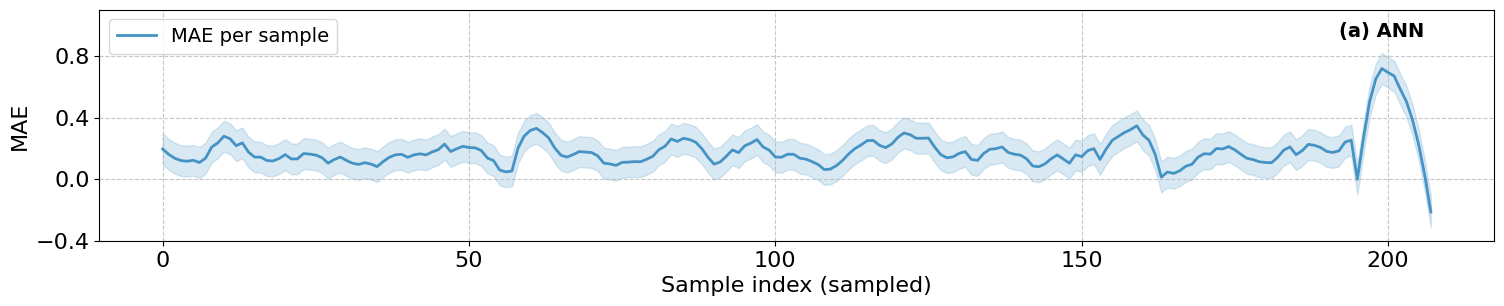

MAE per sample plot saved and displayed: ./ann_fig/mae_per_sample.png


In [25]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator


# 计算每个样本的 MAE
mae_per_sample = np.abs(y_test - y_pred_ann).flatten()

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate = 100
mae_sampled = mae_per_sample[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per sample', color='#4493C4', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.1  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='#4493C4', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=14)

# 在右上角添加文本 (a)
plt.text(0.95, 0.95, '(a) ANN', fontsize=14, fontweight='bold', ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.4, 1.1)
plt.xlim(-10, 250)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.4))

# 保存图像
mae_timestep_path = './ann_fig/mae_per_sample.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per sample plot saved and displayed: {mae_timestep_path}")

In [8]:
# 计算并保存 df_plot 与重采样网格（noTL_docs/ann）——最小改动，不改绘图
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# 1) 在全数据上生成 df_plot（需要已训练好的 model_ann 与 scaler_x/scaler_y）
df_full = pd.read_csv('data.csv')
df_full.drop_duplicates(inplace=True)

# 第一列 Angle，第二列 Strain，第三列真实应力
x_full = df_full.iloc[:, :2].values
y_full_true_original = df_full.iloc[:, 2].values

# 归一化并预测
y_full_pred_scaled = model_ann.predict(scaler_x.transform(x_full))
y_full_pred_original = scaler_y.inverse_transform(y_full_pred_scaled)

# 绝对误差（原始量纲）
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_original.flatten())

# 构造 df_plot 并保存
df_plot = pd.DataFrame({
    'Strain': x_full[:, 1],
    'Angle': x_full[:, 0],
    'Error': absolute_error
})

out_dir = './noTL_docs/ann'
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'df_plot.csv'), index=False)

# 2) 分步式插值生成重采样网格，并保存为 npy/npz
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

# 按角度分组后，沿应变方向插值对齐
aligned_errors = {}
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f(strain_common)

# 沿角度方向插值，得到最终二维误差网格
final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i in range(len(strain_common)):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    current_errors = np.array(current_errors)
    valid_angles = np.array(valid_angles)
    valid_mask = ~np.isnan(current_errors)
    if np.sum(valid_mask) > 1:
        g = interp1d(valid_angles[valid_mask], current_errors[valid_mask], bounds_error=False, fill_value=np.nan)
        final_grid_error[:, i] = g(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# 保存数组
np.save(os.path.join(out_dir, 'strain_common.npy'), strain_common)
np.save(os.path.join(out_dir, 'angle_grid_dense.npy'), angle_grid_dense)
np.save(os.path.join(out_dir, 'final_grid_error.npy'), final_grid_error)
np.savez(os.path.join(out_dir, 'ann_grids.npz'),
         strain_common=strain_common,
         angle_grid_dense=angle_grid_dense,
         final_grid_error=final_grid_error)

print(f"df_plot 与网格已保存至: {out_dir}")

3237/3237 [==============================] - 3s 800us/step
df_plot 与网格已保存至: ./noTL_docs/ann


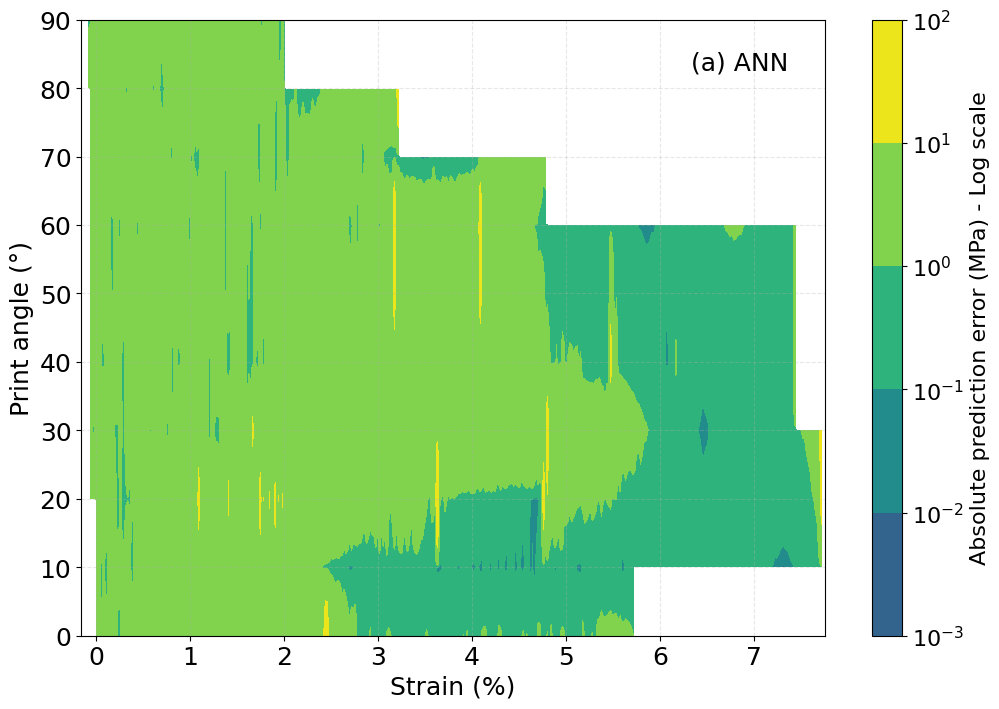


这张字体格式修正后的图表已保存至: ./ann_fig/ann_error_contour_log_scale_formatted.png


In [9]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 假设 df_plot DataFrame 已经从之前的代码块计算得出 ---
# 它包含 'Strain', 'Angle', 'Error' 三列

# --- 步骤 1: 采用与之前相同的、最可靠的分步式插值方法 ---
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())

grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        interp_func = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = interp_func(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i, s in enumerate(strain_common):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    valid_indices = ~np.isnan(current_errors)
    if np.sum(valid_indices) > 1:
        interp_func_angle = interp1d(
            np.array(valid_angles)[valid_indices],
            np.array(current_errors)[valid_indices],
            bounds_error=False,
            fill_value=np.nan
        )
        final_grid_error[:, i] = interp_func_angle(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# --- 步骤 2: 使用“对数色阶”来绘制最终的、对比度增强的图表 ---
target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)

# 使用对数归一化 (LogNorm)
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
norm = mcolors.LogNorm(vmin=min_error_for_log, vmax=df_plot['Error'].max())

# 在绘图时传入 norm 参数
contour = ax.contourf(target_strain, target_angle, final_grid_error_masked, levels=100, cmap='viridis', norm=norm)

# --- 格式化图表 ---
# 添加颜色条和标签
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16) # 调整为16

# --- 【核心修正】: 设置颜色条刻度标签的字体大小 ---
cbar.ax.tick_params(labelsize=16) # 您可以根据需要调整这里的数值 (例如 12, 14, 16)

# 统一所有字体大小
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print angle (°)', fontsize=18)
# ax.set_title('Error contour plot with logarithmic scale (ANN model)', fontsize=20) # 标题改为句首字母大写
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18) # 调整坐标轴刻度字体

ax.text(0.95, 0.95, '(a) ANN', 
        transform=ax.transAxes, 
        fontsize=18, 
        ha='right', 
        va='top')

# 保存最终图像
final_plot_path = './ann_fig/ann_error_contour_log_scale_formatted.png'
plt.savefig(final_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n这张字体格式修正后的图表已保存至: {final_plot_path}")

In [7]:
# 计算 Angle_group_5.csv 的 MAE / RMSE / R²（全量与 Strain<2.7）并保存
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 目录确保
os.makedirs(os.path.join('ann_fig', 'prediction'), exist_ok=True)

# 读取未见测试数据
file_name = 'Angle_group_5.csv'
df_new = pd.read_csv(file_name)

# 训练时 x 的列顺序为 [Angle, Strain]；这里使用前两列作为输入
x_new = df_new.iloc[:, :2].values
strain = df_new.iloc[:, 1].values  # 第二列应变
stress_true = df_new.iloc[:, 2].values.reshape(-1, 1)  # 第三列真实应力

# 归一化+预测+反归一化到原始量纲
x_new_scaled = scaler_x.transform(x_new)
stress_pred_scaled = model_ann.predict(x_new_scaled)
stress_pred = scaler_y.inverse_transform(stress_pred_scaled)

# 扁平化为 1D
true_all = stress_true.flatten()
pred_all = stress_pred.flatten()

# 全量指标
mse_all = mean_squared_error(true_all, pred_all)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, pred_all)
r2_all = r2_score(true_all, pred_all)

# 阈值内（与绘图一致）：Strain < 2.7
strain_threshold = 2.7
mask = strain < strain_threshold
true_thr = true_all[mask]
pred_thr = pred_all[mask]

mse_thr = mean_squared_error(true_thr, pred_thr)
rmse_thr = np.sqrt(mse_thr)
mae_thr = mean_absolute_error(true_thr, pred_thr)
r2_thr = r2_score(true_thr, pred_thr)

# 打印结果
print('=== Angle_group_5.csv metrics ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
print(f'Strain<2.7   -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')

# 保存至 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<2.7', 'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join('ann_fig', 'prediction', 'Angle_group_5_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')



79/79 [==============================] - 0s 1ms/step
=== Angle_group_5.csv metrics ===
All samples   -> MAE=0.9542, RMSE=2.1509, R²=0.9759
Strain<2.7   -> MAE=0.6150, RMSE=0.7467, R²=0.9972
Metrics saved to: ann_fig/prediction/Angle_group_5_metrics.csv


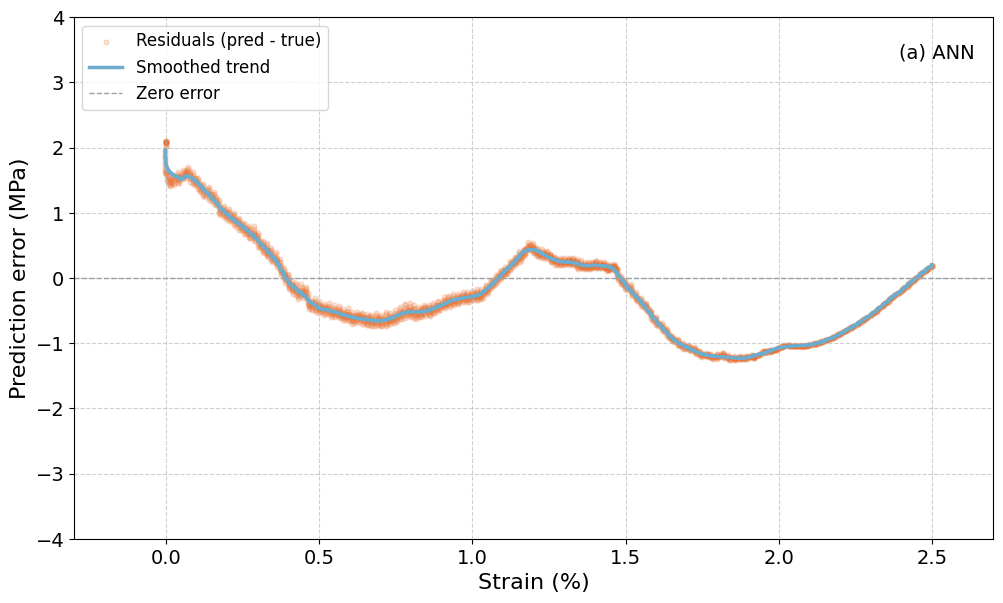

Saved: ann_fig/prediction/ann_residuals_vs_strain_le2.5.png


In [27]:
# 残差(预测-真实) vs 应变：Strain≤阈值（ANN）
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# <<< 手动：这里改参数 >>>
Y_LIMIT    = (-4, 4)   # 手动控制 Y 轴范围（单位 MPa）
STRAIN_MAX = 2.5         # 手动控制数据筛选阈值：仅保留应变 ≤ 此值
X_RANGE    = (-0.3, 2.7) # 手动控制 X 轴显示范围

folder_path = os.path.join('ann_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 读取未见测试集
file_name = 'Angle_group_5.csv'
df_new = pd.read_csv(file_name)

# 特征与目标（列顺序：[Angle, Strain, Stress]）
x_new = df_new.iloc[:, :2].values
strain = df_new.iloc[:, 1].values
stress_true = df_new.iloc[:, 2].values

# 归一化 + 预测 + 反归一化（使用当前会话中的 scaler 与模型）
x_new_scaled = scaler_x.transform(x_new)
y_pred_scaled = model_ann.predict(x_new_scaled, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 计算带符号残差（pred - true），并按 STRAIN_MAX 筛选
min_len = min(len(strain), len(y_pred), len(stress_true))
strain = strain[:min_len]
true_all = stress_true[:min_len]
pred_all = y_pred[:min_len]
residual_all = pred_all - true_all

mask = strain <= STRAIN_MAX
s = strain[mask]
r = residual_all[mask]

# 按应变排序便于平滑与趋势展示
order = np.argsort(s)
s = s[order]
r = r[order]

# Savitzky-Golay 平滑（自适应窗口，奇数）
n = len(r)
if n >= 11:
    window_length = min(101, max(11, (n // 10) * 2 + 1))  # 约10%长度，≤101 且为奇数
    polyorder = 2 if window_length > 3 else 1
    r_smooth = savgol_filter(r, window_length, polyorder)
else:
    r_smooth = r

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(s, r, s=12, color='#E97132', alpha=0.2, label='Residuals (pred - true)')
plt.plot(s, r_smooth, color='#6CADCD', linewidth=2.5, label='Smoothed trend')
plt.axhline(0, color='#9AA0A6', linestyle='--', linewidth=1, label='Zero error')

plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Prediction error (MPa)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')

# 轴范围（手动）
plt.xlim(*X_RANGE)                 # <<< 手动：X 轴范围
if Y_LIMIT is not None:
    plt.ylim(*Y_LIMIT)             # <<< 手动：Y 轴范围

# 左上角角标与模型名
plt.text(0.98, 0.95, '(a) ANN'.format(STRAIN_MAX),
         transform=plt.gca().transAxes, fontsize=14, ha='right', va='top')

plt.tight_layout(pad=0.6)
out_path = os.path.join(folder_path, 'ann_residuals_vs_strain_le{:.1f}.png'.format(STRAIN_MAX))
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved: {out_path}')

In [28]:
import os, numpy as np, pandas as pd

# 1) 读取测试集（本例：Angle_group_5）
df = pd.read_csv('Angle_group_5.csv')
x_new = df.iloc[:, :2].values
strain = df.iloc[:, 1].values
stress_true = df.iloc[:, 2].values

# 2) 归一化 + 预测 + 反归一化（每个模型用自己的 scaler/model）
x_new_scaled = scaler_x.transform(x_new)
y_pred_scaled = model_ann.predict(x_new_scaled, verbose=0)  # 换成你的模型预测
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 3) 计算残差并导出
residual = y_pred[:len(stress_true)] - stress_true[:len(y_pred)]
out_dir = 'ann_fig/prediction'  # 换成各模型自己的目录
os.makedirs(out_dir, exist_ok=True)
pd.DataFrame({'strain': strain[:len(residual)], 'residual': residual}).to_csv(
    os.path.join(out_dir, 'residuals_ANN.csv'), index=False)
print('saved:', os.path.join(out_dir, 'residuals_ANN.csv'))

saved: ann_fig/prediction/residuals_ANN.csv
